# CE 310 — Week 12 Lab
## Sensitivity Analysis: How Uncertainty in Inputs Propagates to Outputs

**Dataset:** `Week5_DOE_MedOffice_ZoneTemp_2023.csv`
**Models:** Model 2 (additive: Cooling ~ Outdoor_Temp_F + BH) and Model 5 (interaction)
**New concept:** No new Python library — sensitivity analysis uses the regression coefficients
you already computed in Weeks 9–10, applied in a new way.

---
**Run all cells in order.** Fill every blank marked `___`.

## Before You Begin

**File needed:** `Week5_DOE_MedOffice_ZoneTemp_2023.csv`  
This is the same dataset from Weeks 5–7 (Excel) and Weeks 9–11 (Python).

**Upload options:**
1. **Colab Files panel (easiest):** Click the folder icon in the left sidebar → click the upload icon → select the CSV file from your computer.
2. **Google Drive mount:** Click the Drive mount button in the Files panel and navigate to the file.

> If you see `FileNotFoundError`, the CSV is not in Colab's working directory — go back and upload it first.

## What Is Sensitivity Analysis?

A regression model converts inputs (outdoor temperature, occupancy) into a predicted output
(cooling energy). In practice, *inputs are uncertain*:
- The outdoor temperature you use to forecast next summer may differ from reality by several °F.
- The number of occupied hours may change if the schedule shifts.
- The regression coefficients themselves carry uncertainty (standard errors).

**Sensitivity analysis** answers: *if one input changes by X, how much does the output change?*

Three complementary approaches used in this lab:
1. **Analytical:** for a linear model, sensitivity = coefficient (dŷ/dX = β)
2. **One-at-a-time (OAT):** perturb one input, hold others fixed, measure output change
3. **Tornado diagram:** rank inputs by their output swing (visual summary of importance)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print('Libraries loaded.')

In [ ]:
df = pd.read_csv('Week5_DOE_MedOffice_ZoneTemp_2023.csv')
df['BH'] = (df['BusinessHours'] == 'Yes').astype(int)

# Refit the two key models from Week 10
m2 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F + BH', data=df).fit()
m5 = smf.ols('Cooling_kWh ~ Outdoor_Temp_F * BH', data=df).fit()

# Extract Model 2 coefficients
i2  = m2.params['Intercept']
b2  = m2.params['Outdoor_Temp_F']
bh2 = m2.params['BH']

# Extract Model 5 slopes
occ_slope   = m5.params['Outdoor_Temp_F'] + m5.params['Outdoor_Temp_F:BH']
unocc_slope = m5.params['Outdoor_Temp_F']

print(f'Model 2: intercept={i2:.4f}, slope={b2:.4f}, BH_coef={bh2:.4f}')
print(f'Model 5: occupied slope={occ_slope:.4f}, unoccupied slope={unocc_slope:.4f}')

---
## Section A — Analytical and Numerical Sensitivity Foundations

We will use a **design point** of T = 85°F, BH = 1 (a typical summer occupied hour)
as the reference prediction throughout Section A.

### A1 — Baseline Prediction at the Design Point

Compute the Model 2 prediction at outdoor temperature **T = 85°F** during an **occupied hour**
(BH = 1). This is your baseline — all sensitivity calculations will measure deviations from it.

In [ ]:
T_design = 85.0

# Model 2 prediction: intercept + slope*T + BH_coef*BH
base_pred = i2 + b2 * ___ + bh2 * ___

print(f'Model 2 prediction at T={T_design}°F, BH=1: {base_pred:.4f} kWh/hr')

ANSWER_A1_base_occ = round(base_pred, 2)
print(f'ANSWER_A1_base_occ = {ANSWER_A1_base_occ}')

### A2 — Analytical Sensitivity: The Slope IS the Sensitivity

For any linear model  ŷ = β₀ + β₁·T + β₂·BH, the partial derivative with respect to T is:

$$\frac{\partial \hat{y}}{\partial T} = \beta_1$$

This means the **sensitivity is constant** — the prediction changes by exactly β₁ for every
1°F change in outdoor temperature, regardless of where on the temperature axis you are.
No calculus needed: the Model 2 outdoor temperature slope *is* the analytical sensitivity.

In [ ]:
# Analytical sensitivity for Model 2 (kWh per °F)
ANSWER_A2_sens_m2 = round(___, 2)   # hint: it is one of the model coefficients
print(f'ANSWER_A2_sens_m2 = {ANSWER_A2_sens_m2}')
print(f'Interpretation: each 1°F increase in outdoor temp raises cooling by {ANSWER_A2_sens_m2} kWh/hr')

### A3 — Numerical OAT Check: +5°F Temperature Change

Verify the analytical result numerically: compute the change in the Model 2 prediction
when outdoor temperature increases by **5°F** (from 85°F to 90°F), holding BH = 1 fixed.

In [ ]:
T_perturbed = T_design + 5.0

pred_plus5 = i2 + b2 * ___ + bh2 * 1
delta_5F   = pred_plus5 - base_pred

print(f'Prediction at T={T_perturbed}°F, BH=1: {pred_plus5:.4f} kWh/hr')
print(f'Change for +5°F:                       {delta_5F:.4f} kWh/hr')
print(f'Analytical check: 5 × {b2:.4f} = {5*b2:.4f}  ← should match')

ANSWER_A3_delta_5F = round(delta_5F, 2)
print(f'ANSWER_A3_delta_5F = {ANSWER_A3_delta_5F}')

### A4 — Annual Aggregate Sensitivity: What Does ±5°F Mean for the Whole Year?

A systematic temperature bias (e.g., a weather station that consistently reads 5°F too warm)
affects every one of the 8,760 predictions. Because the model is linear, the total annual
change is simply **n × ΔT × slope**.

Compute the **percentage change** in total annual predicted cooling if every hourly outdoor
temperature were 5°F higher than observed.

In [ ]:
annual_base = m2.predict(df).sum()   # total predicted annual cooling, kWh

# Total change for +5°F systematic bias across all 8,760 hours
annual_delta = ___ * 5.0 * ___       # n_hours * deltaT * slope
annual_pct   = annual_delta / annual_base * 100

print(f'Annual base total: {annual_base:,.1f} kWh')
print(f'Annual change for +5°F bias: {annual_delta:,.0f} kWh')
print(f'Percentage change: {annual_pct:.2f}%')

ANSWER_A4_annual_swing_pct = round(annual_pct, 2)
print(f'ANSWER_A4_annual_swing_pct = {ANSWER_A4_annual_swing_pct}')

### A5–A7 — Interaction Model: Sensitivity Depends on Occupancy

In the additive Model 2, dŷ/dT is the same for all hours. In the interaction Model 5,
the slope is **different when occupied vs. unoccupied**:

| Condition | Slope (dŷ/dT) |
|---|---|
| Unoccupied (BH=0) | β_outdoor |
| Occupied (BH=1)   | β_outdoor + β_interaction |

Extract both slopes, then compute their ratio — this tells you how much more sensitive
the system is to outdoor temperature when occupied.

In [ ]:
ANSWER_A5_sens_occ_m5   = round(___, 2)   # occupied slope from Model 5
ANSWER_A6_sens_unocc_m5 = round(___, 2)   # unoccupied slope from Model 5
ANSWER_A7_slope_ratio   = round(occ_slope / unocc_slope, 2)

print(f'Model 5 occupied slope   = {ANSWER_A5_sens_occ_m5} kWh/°F')
print(f'Model 5 unoccupied slope = {ANSWER_A6_sens_unocc_m5} kWh/°F')
print(f'Ratio (occ / unocc)      = {ANSWER_A7_slope_ratio}')
print(f'  → the occupied building is {ANSWER_A7_slope_ratio}× more sensitive to outdoor temp')

print(f'ANSWER_A5_sens_occ_m5   = {ANSWER_A5_sens_occ_m5}')
print(f'ANSWER_A6_sens_unocc_m5 = {ANSWER_A6_sens_unocc_m5}')
print(f'ANSWER_A7_slope_ratio   = {ANSWER_A7_slope_ratio}')

### A8 — Occupied Prediction Swing for ±5°F

Using the interaction model, compute how much the **occupied** prediction changes
when outdoor temperature increases by **5°F**. (The answer is the same at any temperature
because the model is still linear in T.)

In [ ]:
occ_swing_5F = 5.0 * occ_slope

ANSWER_A8_occ_swing_5F = round(occ_swing_5F, 2)
print(f'Occupied cooling changes by {ANSWER_A8_occ_swing_5F} kWh/hr per 5°F increase')
print(f'Compare to unoccupied: {round(5*unocc_slope, 2)} kWh/hr per 5°F — {ANSWER_A7_slope_ratio}× smaller')
print(f'ANSWER_A8_occ_swing_5F = {ANSWER_A8_occ_swing_5F}')

---
## Section B — Extension Questions

**Skim the theory notes; focus on the code.** B1 is a manual written question.
B2–B8 follow the `ANSWER_` convention.

### B1 — Interpretation (Manual · 4 pts)

Using the results from A2–A4, write 3–5 sentences that:
1. Explain in plain language why the slope coefficient and the analytical sensitivity are the same number for a linear model.
2. State what A4 implies for a building energy forecaster who uses TMY (Typical Meteorological Year) data that is systematically 5°F warmer than the actual year.
3. Compare the occupied and unoccupied sensitivities from A5–A6. What physical reason explains why the occupied building reacts more strongly to outdoor temperature?

*Type your answer here:*

### B2 — Tornado Diagram: Ranking Parameter Sensitivity

A **tornado diagram** shows how much the model output changes when each parameter is perturbed
by ±10%, sorted from largest to smallest swing. It identifies which parameters the output is
most sensitive to — and therefore which deserve the most careful estimation.

For each of the three Model 2 parameters (Intercept, Outdoor_Temp_F slope, BH coefficient),
compute the total **swing** = |output at +10%| − |output at −10%| = 2 × |Δ at +10%|,
evaluated at the design point (T = 85°F, BH = 1).

In [ ]:
# Perturb each parameter by ±10% and measure the change in the design-point prediction
params = {'Intercept': i2, 'Outdoor_Temp_F': b2, 'BH': bh2}

swings = {}
for name, val in params.items():
    p_plus  = {k: v for k, v in params.items()}
    p_minus = {k: v for k, v in params.items()}
    p_plus[name]  = val * 1.10
    p_minus[name] = val * 0.90

    pred_plus  = p_plus['Intercept']  + p_plus['Outdoor_Temp_F']*T_design  + p_plus['BH']
    pred_minus = p_minus['Intercept'] + p_minus['Outdoor_Temp_F']*T_design + p_minus['BH']
    swings[name] = round(abs(pred_plus - pred_minus), 2)

print('Parameter sensitivity (swing = output range for ±10% perturbation):')
for name, sw in sorted(swings.items(), key=lambda x: -x[1]):
    print(f'  {name:<20}: ±{sw/2:.3f} kWh/hr  |  swing = {sw:.2f} kWh/hr')
print()

ANSWER_B2_swing_T_coef = swings['Outdoor_Temp_F']
ANSWER_B2_swing_int    = swings['Intercept']
ANSWER_B2_swing_BH     = swings['BH']
print(f'ANSWER_B2_swing_T_coef = {ANSWER_B2_swing_T_coef}')
print(f'ANSWER_B2_swing_int    = {ANSWER_B2_swing_int}')
print(f'ANSWER_B2_swing_BH     = {ANSWER_B2_swing_BH}')

**Target shape for B2:**

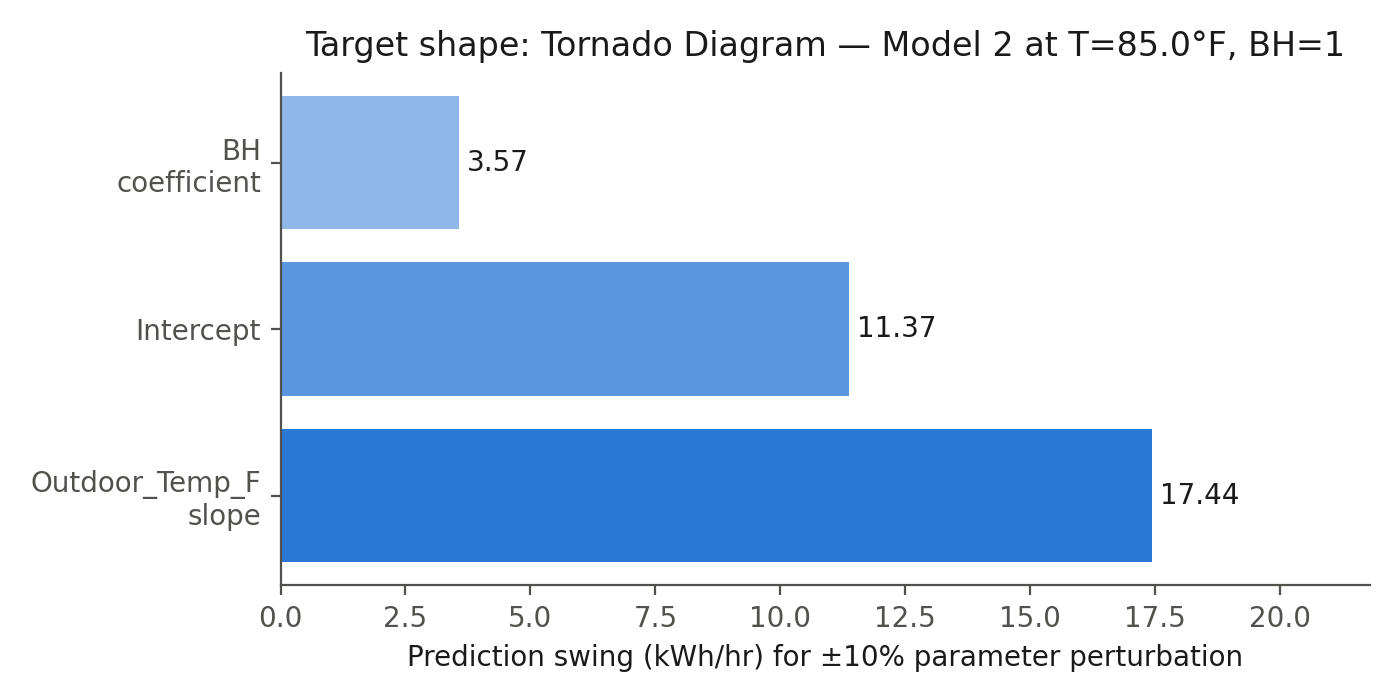


In [ ]:
# Plot the tornado diagram
labels = ['Outdoor_Temp_F\nslope', 'Intercept', 'BH\ncoefficient']
values = [swings['Outdoor_Temp_F'], swings['Intercept'], swings['BH']]

# Sort ascending — barh() plots the first list item at the BOTTOM of the axis,
# so an ascending sort puts the largest swing at the TOP (standard tornado convention)
sorted_pairs = sorted(zip(values, labels))
values_sorted  = [p[0] for p in sorted_pairs]
labels_sorted  = [p[1] for p in sorted_pairs]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(labels_sorted, values_sorted, color=['#90CAF9','#42A5F5','#2196F3'])
ax.set_xlabel('Prediction swing (kWh/hr) for ±10% parameter perturbation')
ax.set_title(f'Tornado Diagram — Model 2 at T={T_design}°F, BH=1')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_xlim(0, max(values_sorted) * 1.25)
plt.tight_layout()
plt.show()

### B2 — Read the Diagram Yourself (Ungraded Checkpoint)

The cell above sorted the three bars for you. Before moving on, answer this **without
re-running any code or looking back at the sorted printout** — just from the diagram:

Which of the three parameters should an engineer prioritize monitoring or refining, and why?
Answer using the swing magnitude, not the parameter's position in the model equation and not
the raw size of the coefficient/intercept itself (the Intercept has the largest raw value in
the equation, ≈ −56.87, but that is not the same thing as having the largest swing).

*Type your one-sentence answer here — this is ungraded, but the Week 15 Final Exam asks you
to do exactly this reasoning cold, from three given numbers, with no code to sort them for you.*

### B3 — Unoccupied Swing: How Different Is the Interaction Model?

Using Model 5, compute how much the **unoccupied** cooling prediction changes
for a +5°F temperature increase. Compare this to the occupied swing from A8.

In [ ]:
unocc_swing_5F = 5.0 * ___

ANSWER_B3_unocc_swing_5F = round(unocc_swing_5F, 2)
print(f'Unoccupied swing for +5°F: {ANSWER_B3_unocc_swing_5F} kWh/hr')
print(f'Occupied swing for +5°F:   {ANSWER_A8_occ_swing_5F} kWh/hr')
print(f'Ratio: {round(ANSWER_A8_occ_swing_5F / ANSWER_B3_unocc_swing_5F, 2)}×  (occupied much more sensitive)')
print(f'ANSWER_B3_unocc_swing_5F = {ANSWER_B3_unocc_swing_5F}')

### B4 — Annual kWh Sensitivity: Model 2 (Absolute Change)

Compute the **additional kilowatt-hours** of cooling the building would use in a year
if every hourly outdoor temperature were 5°F higher than recorded.
Report as an integer (kWh).

In [ ]:
annual_delta_kwh = round(___ * 5.0 * ___)   # n_hours × deltaT × slope, rounded to integer

ANSWER_B4_annual_sens_m2 = annual_delta_kwh
print(f'Additional annual cooling for +5°F bias: {ANSWER_B4_annual_sens_m2:,} kWh')
print(f'As % of annual total: {annual_delta_kwh/annual_base*100:.1f}%')
print(f'ANSWER_B4_annual_sens_m2 = {ANSWER_B4_annual_sens_m2}')

### B5 — Occupancy Schedule Sensitivity (Manual · 4 pts)

A facilities manager considers extending business hours by **1 hour per weekday**.
There are 260 weekdays per year, so this adds **260 occupied hours** annually.

Compute the additional annual cooling energy from these 260 extra occupied hours.

In [ ]:
extra_hours = 260

ANSWER_B5_occ_hours_sens = round(extra_hours * ___)   # additional hours × BH coefficient
print(f'Additional cooling from 260 more occupied hours: {ANSWER_B5_occ_hours_sens:,} kWh/yr')
print(f'As % of annual total: {ANSWER_B5_occ_hours_sens/annual_base*100:.2f}%')
print(f'ANSWER_B5_occ_hours_sens = {ANSWER_B5_occ_hours_sens}')

**B5 Tornado Plot — Manual (4 pts)**

Expand the tornado diagram from B2 to include a fourth bar for the **occupancy-schedule
sensitivity** (B5 result, expressed as swing in annual kWh/yr rather than kWh/hr).

Note: the B2 tornado diagram used kWh/hr at a single design point. For B5, the metric is
annual kWh — a different scale. The manual task is to **sketch or annotate** a conceptual
comparison: which source of uncertainty (temperature measurement error vs. schedule change)
is larger in absolute annual impact? Include your sketch or written comparison below.

*Type your answer here:*

### B6 — Design Temperature Uncertainty (Model 5)

At the **ASHRAE 0.4% design temperature** (T = 103.8°F, occupied), a ±5°F uncertainty
in the design temperature translates to a ±X% uncertainty in the peak cooling prediction.

Compute the **percentage uncertainty** in the Model 5 occupied prediction at 103.8°F
for a ±5°F temperature swing.

In [ ]:
T_ashrae = 103.8
i5  = m5.params['Intercept']
bh5 = m5.params['BH']
base_m5_occ = occ_slope * T_ashrae + (i5 + bh5)   # Model 5 occupied prediction

swing_5F_m5 = 5.0 * occ_slope                      # change for ±5°F
uncert_pct  = swing_5F_m5 / base_m5_occ * 100

print(f'Model 5 occupied prediction at {T_ashrae}°F: {base_m5_occ:.2f} kWh/hr')
print(f'Swing for ±5°F:                              ±{swing_5F_m5:.2f} kWh/hr')
print(f'Percentage uncertainty:                       ±{uncert_pct:.2f}%')

ANSWER_B6_design_uncert_pct = round(uncert_pct, 2)
print(f'ANSWER_B6_design_uncert_pct = {ANSWER_B6_design_uncert_pct}')

### B7 — Annual Sensitivity: Model 5 vs. Model 2

Compute the total additional annual cooling (kWh) for a +5°F systematic bias using **Model 5**.
Remember that occupied and unoccupied hours have different slopes.
Report as an integer.

In [ ]:
n_occ   = df['BH'].sum()           # occupied hours
n_unocc = (df['BH'] == 0).sum()    # unoccupied hours

annual_delta_m5 = round(n_occ * 5.0 * ___ + n_unocc * 5.0 * ___)  # occ + unocc portions

ANSWER_B7_m5_annual_sens = annual_delta_m5
print(f'Model 5 annual sensitivity (+5°F): {ANSWER_B7_m5_annual_sens:,} kWh')
print(f'Model 2 annual sensitivity (+5°F): {ANSWER_B4_annual_sens_m2:,} kWh')
print(f'Difference: {abs(ANSWER_B7_m5_annual_sens - ANSWER_B4_annual_sens_m2):,} kWh  ({abs(ANSWER_B7_m5_annual_sens - ANSWER_B4_annual_sens_m2)/annual_base*100:.2f}% of annual total)')
print(f'ANSWER_B7_m5_annual_sens = {ANSWER_B7_m5_annual_sens}')

### B8 — Sensor Accuracy Threshold

If a temperature sensor has an error of ε °F (°F off from true value), the Model 2
occupied prediction at 85°F will have an error of ε × slope kWh/hr.

Compute: **how many °F of sensor error would produce a 10% error** in the Model 2
prediction at the design point (T = 85°F, BH = 1)?

This is the sensor-accuracy specification required to keep cooling predictions within 10%.

In [ ]:
target_error_kwh = 0.10 * base_pred    # 10% of baseline prediction
T_threshold      = target_error_kwh / ___   # divide by slope to get equivalent °F error

ANSWER_B8_T_threshold = round(T_threshold, 2)
print(f'10% of design-point prediction = {target_error_kwh:.3f} kWh/hr')
print(f'Temperature threshold for 10% error: ±{ANSWER_B8_T_threshold} °F')
print(f'(Sensors accurate to ±0.5°F are well within this threshold)')
print(f'ANSWER_B8_T_threshold = {ANSWER_B8_T_threshold}')

### B9 — Written Reflection (Manual · 4 pts)

Using the results from B2 (tornado diagram), B4, B5, and B7, write 4–6 sentences:

1. Which input (outdoor temperature measurement, occupancy coefficient, or intercept)
   contributes the most to prediction uncertainty at a single design point, and by how
   much more than the least sensitive input?
2. Comparing B4 and B5: a 5°F temperature bias affects annual energy by
   ≈44,936 kWh; extending hours by 260 adds ≈4,642 kWh. What does this ratio tell
   a building manager about where to focus effort in reducing energy prediction uncertainty?
3. Why do Model 2 and Model 5 give nearly identical annual sensitivity to temperature
   (B4 vs. B7), even though their occupied and unoccupied slopes differ by 2.5×?

*Type your answer here:*

---
## Memo (Manual · 8 pts)

Write a **3-paragraph technical memo** to a project engineer summarising what sensitivity
analysis reveals about the reliability of this building's cooling energy model.
Use your own computed numbers — do not copy them from the prompts.

**Paragraph 1 — Analytical sensitivity (3 pts)**  
Cover: what the Model 2 slope tells you about temperature sensitivity, whether the sensitivity
is constant across temperatures, and what the A4 annual-aggregate result implies for using
typical-year vs. actual-year weather data.

**Paragraph 2 — Tornado diagram ranking (3 pts)**  
Cover: which of the three Model 2 parameters drives the most output uncertainty and which
drives the least, the relative magnitude of the swings, and the practical engineering
implication (what should you pin down most carefully when applying this model?).

**Paragraph 3 — Interaction model insight (2 pts)**  
Cover: the ratio of occupied to unoccupied slopes from Model 5 (A7), what this means for
the risk of under-sizing cooling equipment, and whether temperature measurement accuracy
is more critical for occupied or unoccupied load estimates.

*Type memo here:*

---
## Looking Ahead: Week 13 — Monte Carlo Simulation

Sensitivity analysis answered: *if one input shifts by a fixed amount, how does the output change?*

**Monte Carlo simulation** goes further: *if each input is uncertain with a known probability
distribution, what is the full probability distribution of the output?*

Rather than testing ±5°F as a single scenario, Monte Carlo draws thousands of random
temperature values from a distribution (e.g., Normal(μ=85°F, σ=5°F)), runs the model
for each draw, and builds a histogram of predicted outputs. The result is a prediction
interval — exactly what an engineer needs to size equipment for risk-acceptable performance.

---
## Before You Submit

> ⚠️ Your saved cell **outputs** are what get read, not your code. If you skip this step, every numeric question scores 0 — even if your formulas are correct.

**Step 1 — Run All Cells:**
In the menu bar: **Runtime → Run all** (Google Colab) or **Kernel → Restart & Run All** (Jupyter).
Wait until every cell shows output — no spinning circles.

**Step 2 — Check your ANSWER_ lines:**
Each graded cell should print a line like `ANSWER_A1 = 23.45`. If any prints `None` or is missing, fix the code and re-run.

**Step 3 — Download and upload:**
- File → Download → **Download .ipynb** (not PDF, not .py)
- Rename: `lastname_firstname_week12.ipynb`
- Upload to D2L before the deadline

**Submission checklist:**
- [ ] All cells ran without error (no red tracebacks)
- [ ] Every `ANSWER_` variable prints a number (not `None`)
- [ ] Memo paragraphs are filled in (not placeholder text)
- [ ] File downloaded as `.ipynb` — not PDF, not `.py`
- [ ] File renamed: `lastname_firstname_week12.ipynb`
